In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

In [4]:
timed_relevance_path = '/home/rachel/Desktop/drosophila_sleep_analysis/binned_beam_break/mlp_ld20_std10_1000ep/relevance_ordered.csv'

In [5]:
timed_relevance = pd.read_csv(timed_relevance_path)
timed_relevance

,0
0,0.018235
1,0.029438
2,0.016939
3,0.029967
4,0.020176
...,...
5012,0.464880
5013,0.722352
5014,0.570885
5015,0.415266


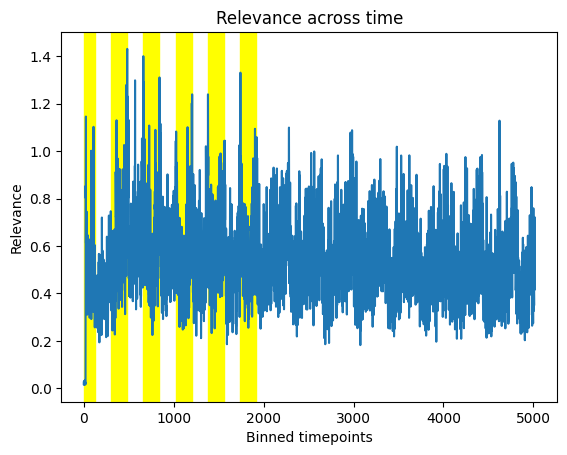

In [6]:
# plot light cycle
light_cycle = ([0, 480], [1200, 1920], [2640, 3360], [4080, 4800], [5520, 6240], [6960, 7680]) 
fig, ax = plt.subplots()
ax.plot(timed_relevance)
ax.set_title('Relevance across time')
ax.set_xlabel('Binned timepoints')
ax.set_ylabel('Relevance')
for i, (start, end) in enumerate(light_cycle):
    ax.axvspan(start / 4, end / 4, color='yellow', label = 'light')

Freuency decomposition of the time relevance signal to examine cyclic nature

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/numpy/lib/histograms.py:841: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7135: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


Text(0.5, 1.0, 'Frequency distribution')

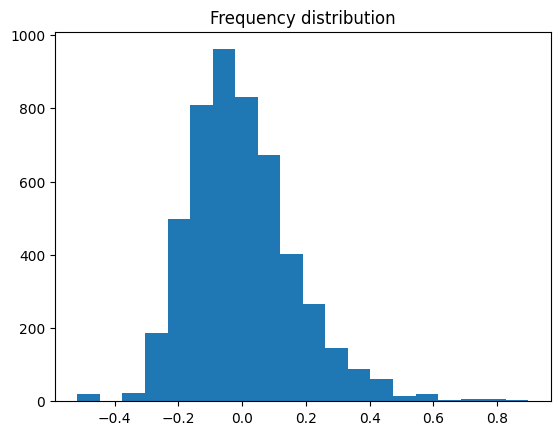

In [7]:
y_fft = fft(timed_relevance - np.mean(timed_relevance))
x_fft = fftfreq(len(timed_relevance))
plt.hist(y_fft, bins=20)
plt.title('Frequency distribution')

In [8]:
power = np.abs(y_fft[:len(timed_relevance)//2]) ** 2
np.max(power) / np.mean(power)

23.699298063974073

In [13]:
dominant_x = np.argmax(np.abs(y_fft))
dominant_freq = x_fft[dominant_x]
dominant_freq

0.09627267291209887

In [14]:
amplitude = (np.abs(y_fft)[dominant_x] / 5017) * 2
phase = np.angle(x_fft[dominant_x])

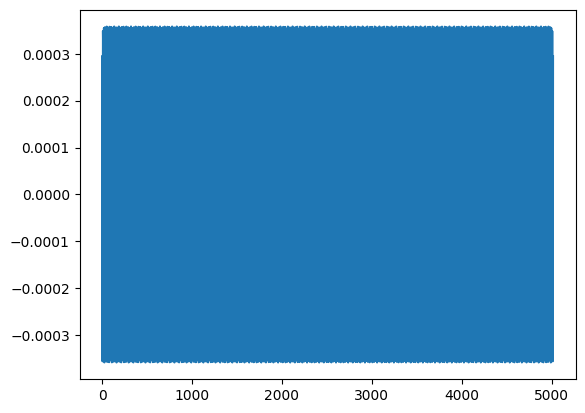

In [16]:
x = np.arange(1, 5017)
y = amplitude * np.cos(2 * np.pi * dominant_freq * x + phase)
plt.plot(x, y)